In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

patient_data = "Person_01/rec_1"
ecg = wfdb.rdrecord(patient_data)
annotations = wfdb.rdann(patient_data, 'atr')
voltages = ecg.p_signal

nvoltages = np.array(voltages)
print(nvoltages.shape)

reshaped_volts = np.reshape(voltages, shape=(2, 10000), copy=True)

#Raw Signal
print(f"Channel 1 : {reshaped_volts[0]}")
#Filtered Signal
print(f"Channel 2 : {reshaped_volts[1]}")
#Annotations
print(annotations.sample)
print(annotations.symbol)

(10000, 2)
Channel 1 : [-0.085 -0.115 -0.08  ...  0.095  0.04   0.095]
Channel 2 : [ 0.025  0.095  0.02  ... -0.035 -0.08  -0.035]
[ 352  469  727  839 1135 1246 1599 1715 2067 2183 2525 2638 2992 3109
 3436 3556 3870 3980 4293 4407]
['N', 't', 'N', 't', 'N', 't', 'N', 't', 'N', 't', 'N', 't', 'N', 't', 'N', 't', 'N', 't', 'N', 't']


In [2]:
channels = ecg.sig_name
print(channels)

['ECG I', 'ECG I filtered']


In [3]:
#Sample Rate
print("Sample Rate : ", ecg.fs)
#Record Name
print("Record Name : ", ecg.record_name)
#Comments i.e. Name, Age, Gender, Date etc.
print(ecg.comments)

Sample Rate :  500
Record Name :  rec_1
['Age: 25', 'Sex: male', 'ECG date: 07.12.2004']


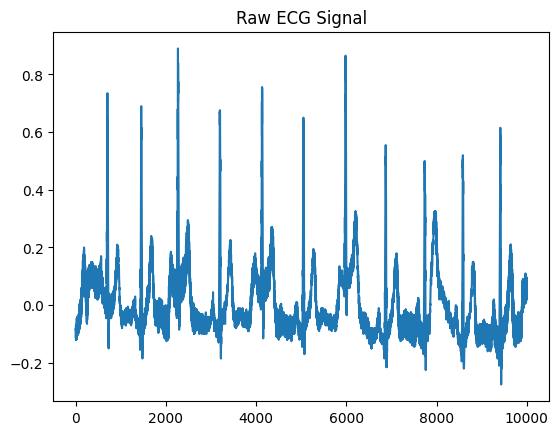

In [4]:
signal = reshaped_volts[0]

x = range(len(signal))
#x = range(2000)
y = signal
plt.plot(x, y)
plt.title("Raw ECG Signal")
plt.show()

In [5]:
samples = annotations.sample
symbols = annotations.symbol

for i, sym in zip(samples, symbols):
    print(f"{i} | {sym}")

352 | N
469 | t
727 | N
839 | t
1135 | N
1246 | t
1599 | N
1715 | t
2067 | N
2183 | t
2525 | N
2638 | t
2992 | N
3109 | t
3436 | N
3556 | t
3870 | N
3980 | t
4293 | N
4407 | t


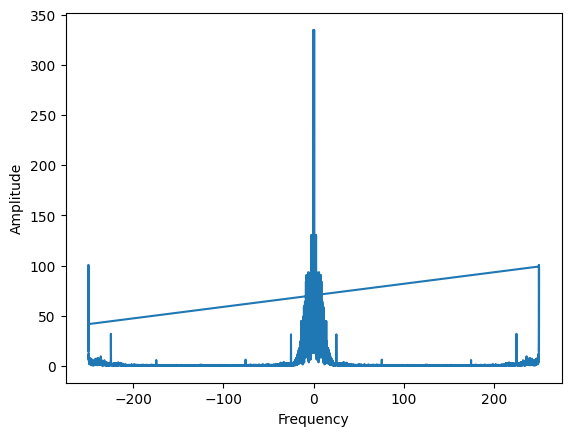

In [57]:
#FFT Generated Code :
fs = 500
sig = reshaped_volts[0]

N = len(sig)
fft_vals = np.fft.fft(sig)
freqs = np.fft.fftfreq(N, d = 1/fs)

mag = np.abs(fft_vals)

ny = N//2

plt.plot(freqs, mag)
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

In [12]:
#Manual DFT Implementation :
'''samplefreq = ecg.fs
N = len(signal)
end = N/samplefreq
X = np.zeros(N, dtype=complex)

for k in range(N):
    total = 0
    for n in range(N):
        ang = 2*np.pi*k*n/N
        total += signal[n]*np.exp(-1j*ang)
    X[k] = total    

freqs = np.arange(N)*samplefreq/N
mag = np.abs(X)/N

plt.plot(freqs, mag)
plt.show()
'''

'samplefreq = ecg.fs\nN = len(signal)\nend = N/samplefreq\nX = np.zeros(N, dtype=complex)\n\nfor k in range(N):\n    total = 0\n    for n in range(N):\n        ang = 2*np.pi*k*n/N\n        total += signal[n]*np.exp(-1j*ang)\n    X[k] = total    \n\nfreqs = np.arange(N)*samplefreq/N\nmag = np.abs(X)/N\n\nplt.plot(freqs, mag)\nplt.show()\n'

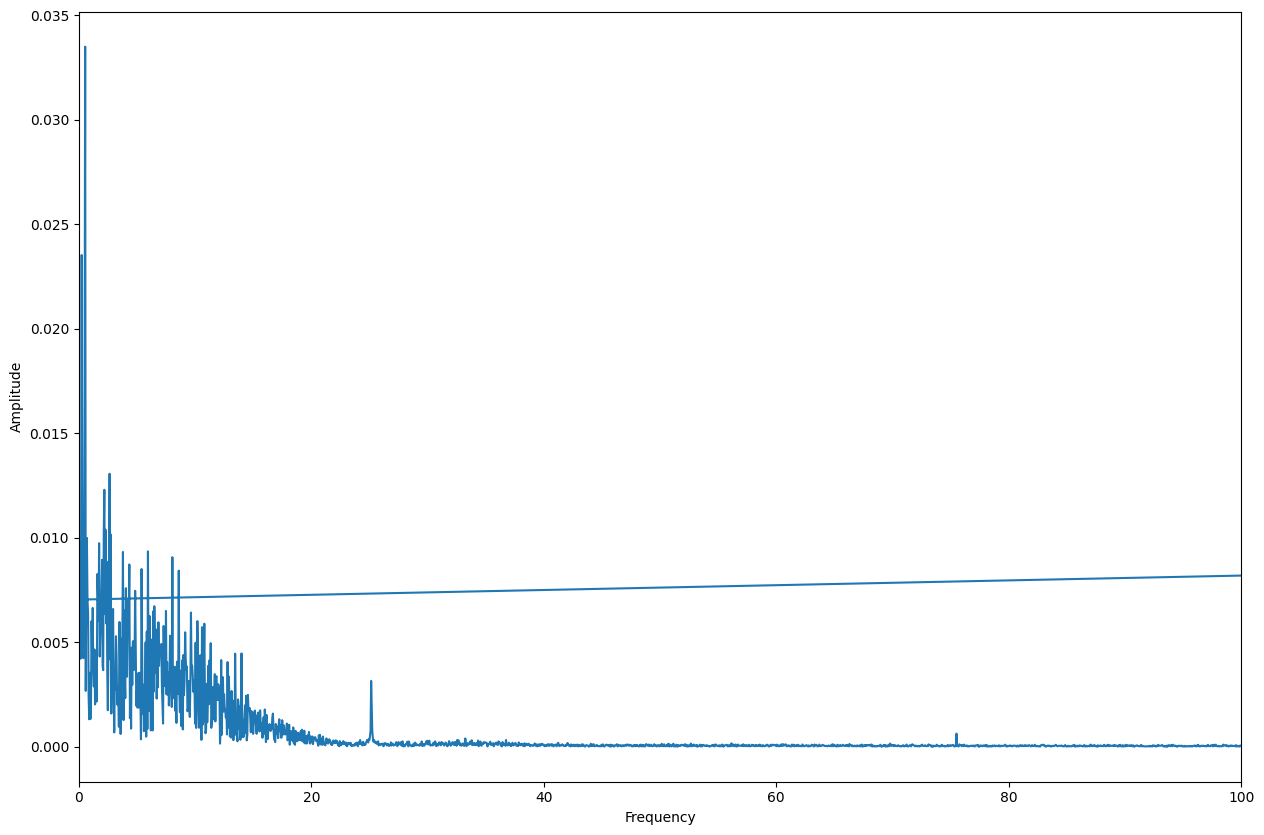

In [7]:
from scipy.fft import fft, ifft, fftfreq

sig = reshaped_volts[0]
fs = 500

N = len(sig)
X = fft(sig)
freqs = fftfreq(N, d=1/fs)
mag = np.abs(X)/N

plt.figure(figsize=(15,10))
plt.plot(freqs, mag)
plt.xlim(0, 100)
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

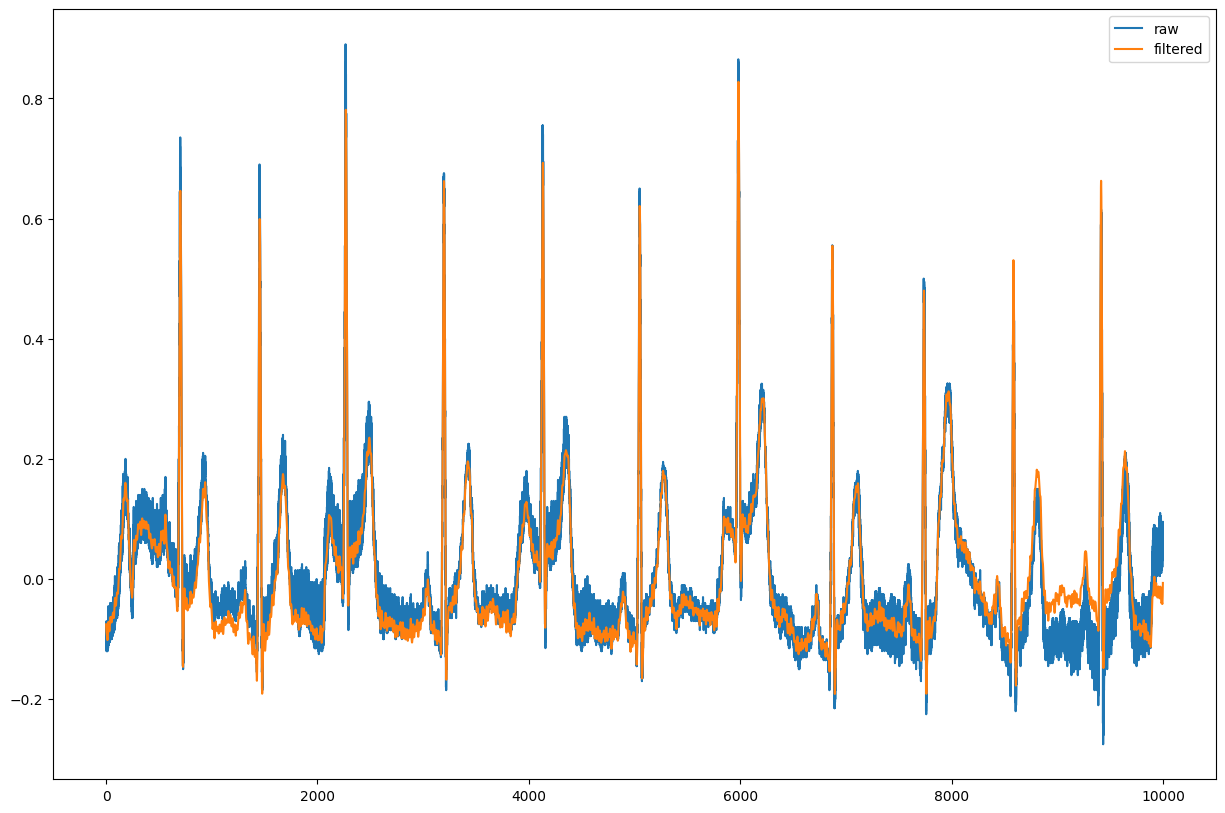

In [86]:
#Applying Butterworth Signal
from scipy.signal import butter, filtfilt, lfilter

l, h = 0.15, 50

b, a = butter(
    N=4,
    Wn = [l, h],
    btype = 'bandpass',
    fs = 500
)

filtsig = filtfilt(b, a, sig)

plt.figure(figsize=(15, 10))
plt.plot(sig, label='raw')
plt.plot(filtsig, label='filtered')
plt.legend()
plt.show()

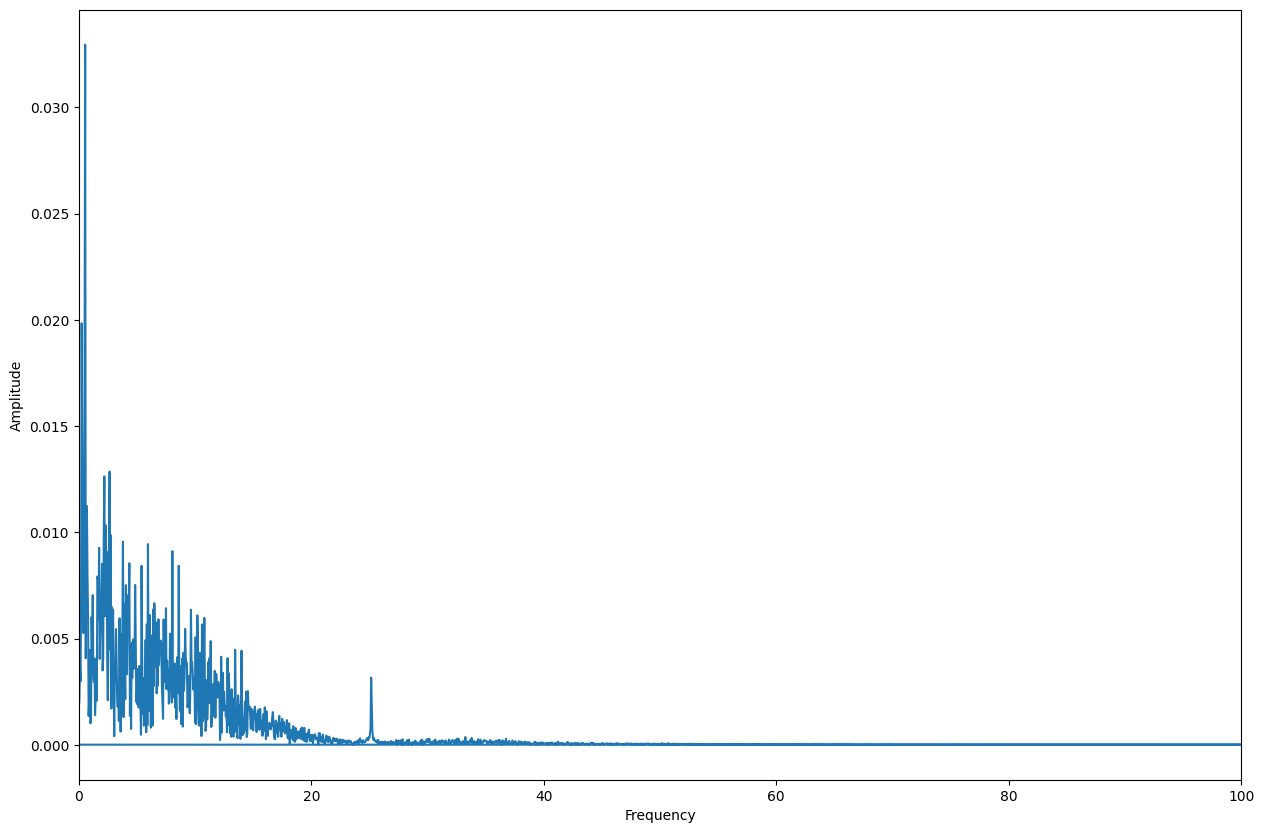

In [87]:
#Recomputing FFT
fs = 500

N = len(filtsig)
X = fft(filtsig)
freqs = fftfreq(N, d=1/fs)
mag = np.abs(X)/N

plt.figure(figsize=(15,10))
plt.plot(freqs, mag)
plt.xlim(0, 100)
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

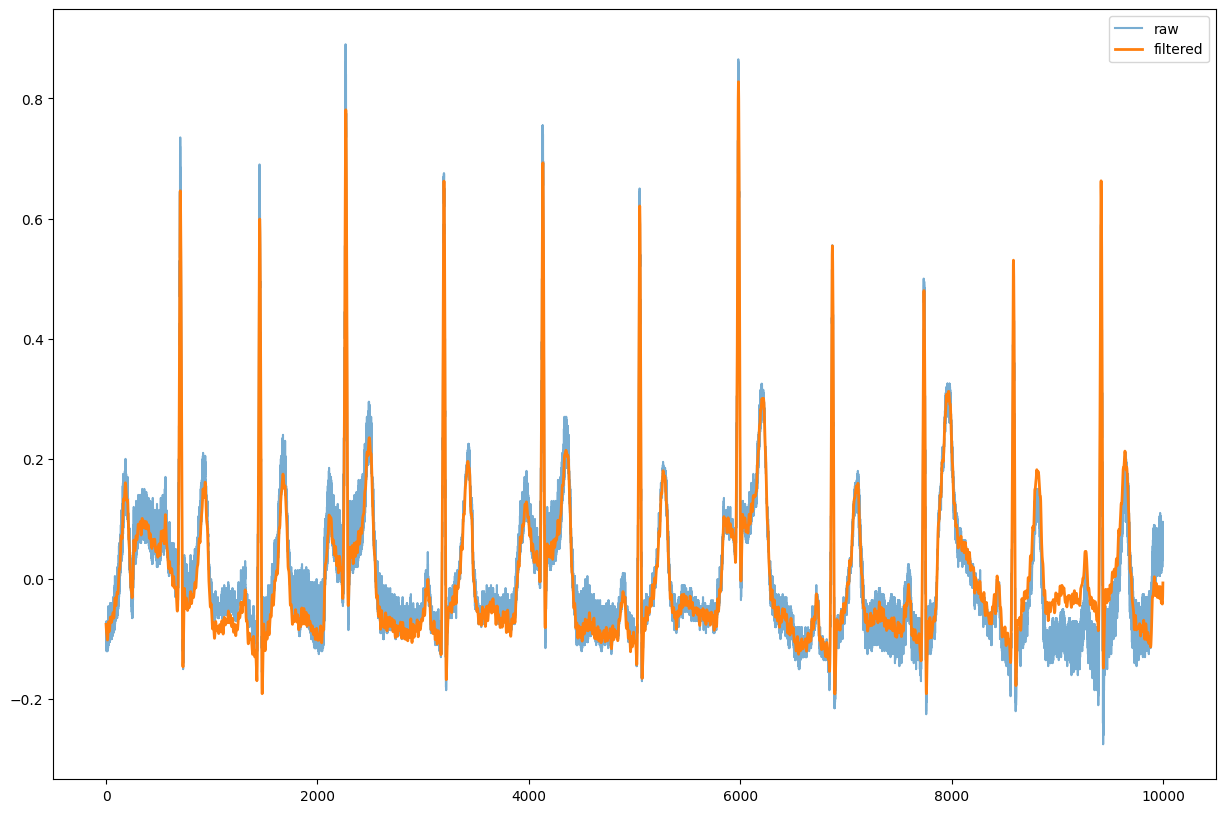

In [88]:
plt.figure(figsize=(15,10))
plt.plot(sig, label="raw", alpha=0.6)
plt.plot(filtsig, label="filtered", linewidth=2)
plt.legend()
plt.show()

In [89]:
window = int(0.02 * fs)  #samples
r_idx = np.argmax(sig)
raw_peak = np.max(sig[r_idx-window:r_idx+window])
filt_peak = np.max(filtsig[r_idx-window:r_idx+window])

print(raw_peak, filt_peak)

0.89 0.780996487989406


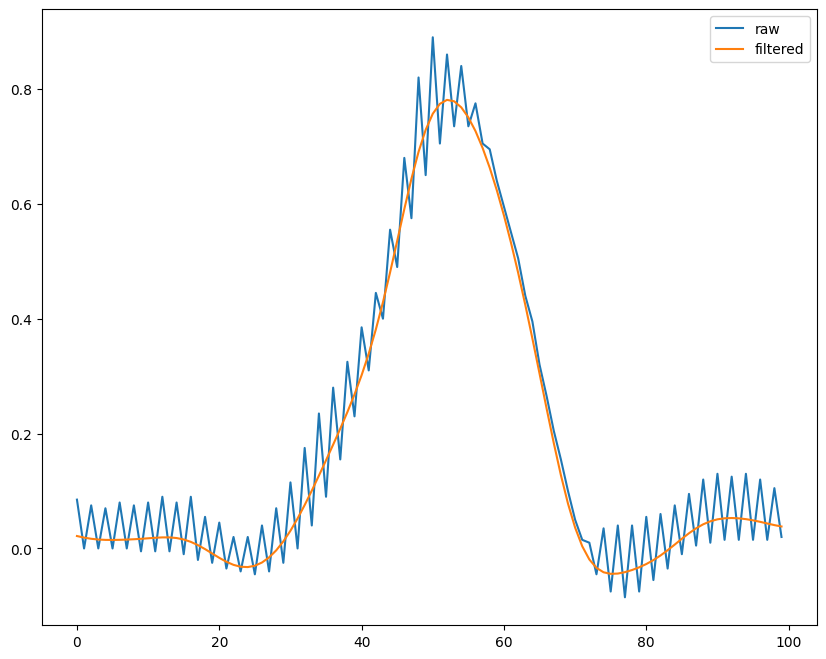

In [90]:
plt.figure(figsize=(10,8))
plt.plot(sig[r_idx-50:r_idx+50], label="raw")
plt.plot(filtsig[r_idx-50:r_idx+50], label="filtered")
plt.legend()
plt.show()

In [91]:
raw_energy = np.sum(sig**2)
filt_energy = np.sum(filtsig**2)

print("Energy ratio:", filt_energy/raw_energy)

Energy ratio: 0.9297931990119239


In [92]:
from scipy.fft import fft, fftfreq
import numpy as np

N = len(sig)
X = fft(sig)
freqs = fftfreq(N, 1/fs)

low_band = np.abs(freqs) < 0.5
low_energy = np.sum(np.abs(X[low_band])**2)
total_energy = np.sum(np.abs(X)**2)

print("Low-freq energy fraction:", low_energy/total_energy)

Low-freq energy fraction: 0.1266007296184019


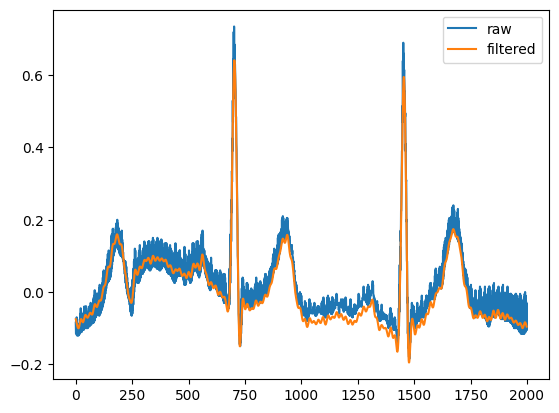

In [84]:
plt.plot(sig[:2000], label='raw')
plt.plot(filtsig[:2000], label='filtered')
plt.legend()

In [96]:
trim = int(0.5 * fs)

ratio = (
    np.sum(filtsig[trim:-trim]**2) /
    np.sum(sig[trim:-trim]**2)
)
print(ratio)

0.9311295628817928


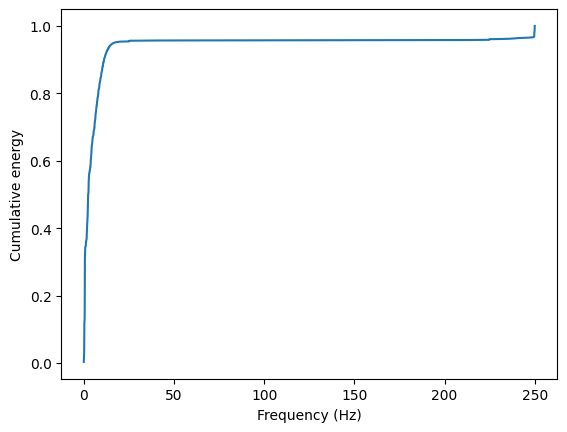

In [97]:
power = np.abs(np.fft.rfft(sig))**2
freqs = np.fft.rfftfreq(len(sig), 1/fs)

cum_energy = np.cumsum(power) / np.sum(power)

plt.plot(freqs, cum_energy)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Cumulative energy')
plt.show()